# CG — alanine dipeptide (gas, 300 K)

Coarse-graining and FRESEAN workflow for alanine dipeptide, using the same all-atom trajectory as `02_MD-alanine-dipeptide-gas-300K.ipynb` (`input_data/MD-gas-300K/`).

| Step | What happens | This notebook |
|------|--------------|---------------|
| Coarse-graining | load AA `topol`/`traj`, map to COM beads | `CoarseGrain.cg_universe()` (§1) |
| FRESEAN (CG) | correlation matrix + modes on CG trajectory | §2 |
| FRESEAN (all-atom) | same frames and spectral parameters | §3 |
| **VDoS comparison** | overlay CG vs all-atom total VDoS | §4 |
| Back-mapping | CG modes → all-atom | `backmap_modes()` (§5) |
| PLUMED prep | mode direction PDB | `write_plumed_mode_input()` (§6) |
| **Un-CG** | `track` vs `ref` backmap, compare reconstructed AA VDoS | §7 |

With four CG beads FRESEAN yields twelve eigenmodes; modes **1 and 2** (1-based) are back-mapped here. If a mode index is missing from the CG spectrum, the all-atom FRESEAN result is used instead.


In [ ]:
import shutil
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import MDAnalysis as mda
import numpy as np
import pandas as pd

from pyfresean import Align, CoarseGrain, FRESEAN
from pyfresean.postprocess import low_frequency_peaks, mode_spectra, plot_spectra

METAD_DATA = Path("fresean_metaD_data") # add in-code commnets explaining different file paths et al.
INPUT_DATA = Path("input_data")
INPUT_DATA.mkdir(parents=True, exist_ok=True)
OUTPUT_DATA = Path("output_data")
OUTPUT_DATA.mkdir(parents=True, exist_ok=True)
AA = INPUT_DATA / "MD-gas-300K"
OUT = OUTPUT_DATA / "MD-gas-300K-CG"
OUT.mkdir(parents=True, exist_ok=True)

for name in ("plumed-mode-projection.dat",):
    src = METAD_DATA / name
    if src.exists():
        shutil.copy2(src, OUT / name)

MODE_NUMBERS = (1, 2)
MODE_INDICES = tuple(m - 1 for m in MODE_NUMBERS)

N_FRAMES = 5000
DT = 0.004  # ps between frames
N_CORR = 100
SIGMA = 10.0
N_CONSTRAINTS_AA = 6


def download_if_needed(path, url):
    path = Path(path)
    if not path.exists():
        path.parent.mkdir(parents=True, exist_ok=True)
        print(f"Downloading {path} ...")
        urllib.request.urlretrieve(url, path)


print(f"All-atom data: {AA.resolve()}")
print(f"Output directory: {OUT.resolve()}")
print(f"Using modes {MODE_NUMBERS} (0-based indices {MODE_INDICES})")


All-atom data: /home/athiru12/Research_experiments_sol/code/FRESEAN_project/FRESEAN_tutorial/pyfresean/examples/input_data/MD-gas-300K
Output directory: /home/athiru12/Research_experiments_sol/code/FRESEAN_project/FRESEAN_tutorial/pyfresean/examples/output_data/MD-gas-300K-CG
Using modes (1, 2) (0-based indices (0, 1))


## 1. Coarse-grain from all-atom files

Each residue maps to a **BACK** (backbone COM) bead and, except GLY/ACE/NME, a **SIDE** (sidechain COM) bead.

`CoarseGrain.cg_universe((topol, traj), select=...)` loads the all-atom topology and trajectory, applies the selection, and returns `(cg, u_cg)`. Pass `output_cg_topology` with a `.top` extension to save bead masses (a companion `.gro` is written automatically). Trajectory files download from the same URLs as notebook 02 if they are not already under `input_data/MD-gas-300K/`.


In [ ]:
topol = AA / "topol.tpr"
traj = AA / "traj.trr"
ref = INPUT_DATA / "harmonic-normal-modes" / "min.xyz"

download_if_needed(
    topol,
    "https://www.dropbox.com/scl/fi/zux7notw4x9omhqj1rngj/topol.tpr?rlkey=svz7x62n0g4sooee10vp968zp&dl=1",
)
download_if_needed(
    traj,
    "https://www.dropbox.com/scl/fi/vhbtq7x3vqdap5t3i0vlw/traj.trr?rlkey=cffmtm0tysiy85bd3luaa46af&dl=1",
)

u_ref = mda.Universe(str(ref))
ref_positions = u_ref.atoms.positions.copy()

cg_top = OUT / "topol-cg.top"
cg_gro = OUT / "topol-cg.gro"
cg_traj = OUT / "traj-cg.trr"
ref_aa_pdb = OUT / "ref.pdb"
ref_cg_pdb = OUT / "ref-cg.pdb"

cg_map_path = OUT / "cg_map.npz"
aa_rotations_path = OUT / "aa_rotations.npz"

for p in (cg_top, cg_gro, cg_traj, cg_map_path, aa_rotations_path):
    if p.exists():
        p.unlink()

cg, u_cg = CoarseGrain.cg_universe( # explain cg, u_cg and other inputs here
    (topol, traj),
    select="all",
    stop=N_FRAMES,
    output_cg_topology=str(cg_top),
    output_cg_trajectory=str(cg_traj),
    output_cg_map=str(cg_map_path),
    output_aa_rotations=str(aa_rotations_path),
    centered_mode="track",
    in_memory=True,
)

# rename cg to cg_mapping
# add types of CGing - 1. 1 bead per residue 2. custom mapping by user

aa_sel = cg.atomgroup
print(f"All-atom atoms: {aa_sel.n_atoms}")
print(f"Source trajectory frames: {len(aa_sel.universe.trajectory)} (using first {N_FRAMES})")

m = cg.mapping
rows = []
for i in range(m.n_beads):
    rows.append(
        {
            "bead": i,
            "type": m.bead_types[i],
            "resname": m.resnames[i],
            "resindex": int(m.resindices[i]),
            "mass": m.bead_masses[i],
            "n_atoms": len(m.atom_indices[i]),
        }
    )

print(f"CG beads: {m.n_beads}")
print(f"n_constraints: {m.n_constraints}")
print(f"Bead masses: {u_cg.atoms.masses}")
pd.DataFrame(rows)

# Shared alignment reference: harmonic minimum mapped to CG COM beads.
ref_cg = cg.map_positions(ref_positions)

# Write ref AA PDB without mutating the trajectory (avoid in-memory frame overwrite).
ref_aa_scratch = mda.Universe(str(topol))
ref_aa_scratch.atoms.positions = ref_positions.astype(np.float32)
ref_aa_scratch.atoms.write(str(ref_aa_pdb))
with open(ref_aa_pdb, "r+", encoding="utf-8") as handle:
    content = handle.read()
    handle.seek(0)
    if not content.startswith("REMARK TYPE=OPTIMAL"):
        handle.write("REMARK TYPE=OPTIMAL\n" + content)

u_cg.trajectory[0]
saved_frame0 = u_cg.atoms.positions.copy()
u_cg.atoms.positions = ref_cg.astype(np.float32)
cg.write_topology(u_cg, str(ref_cg_pdb))
u_cg.atoms.positions = saved_frame0

assert len(u_cg.trajectory) == N_FRAMES
print(f"CG beads: {u_cg.atoms.n_atoms}, frames: {len(u_cg.trajectory)}")


/home/athiru12/.local/lib/python3.13/site-packages/MDAnalysis/coordinates/GRO.py:518: UserWarning: missing dimension - setting unit cell to zeroed box [0., 0., 0.]
  warnings.warn(wmsg)


All-atom atoms: 22
Source trajectory frames: 250001 (using first 5000)
CG beads: 4
n_constraints: 0.0
Bead masses: [43.04400051 56.04600072 15.03400028 30.05200052]
CG beads: 4, frames: 5000


/home/athiru12/.local/lib/python3.13/site-packages/MDAnalysis/coordinates/PDB.py:885: UserWarning: Unit cell dimensions not found. CRYST1 record set to unitary values.
  warnings.warn(
/home/athiru12/.local/lib/python3.13/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'altLocs' Using default value of ' '
  warnings.warn(
/home/athiru12/.local/lib/python3.13/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'icodes' Using default value of ' '
  warnings.warn(
/home/athiru12/.local/lib/python3.13/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'occupancies' Using default value of '1.0'
  warnings.warn(
/home/athiru12/.local/lib/python3.13/site-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'tempfactors' Using default value of '0.0'
  warnings.warn(
/home/athiru12/.local/lib/python3.13/site-packages/MDAnalysis/co

## 2. Align CG trajectory and run FRESEAN

Alignment to CG COM positions mapped from `min.xyz` (same reference as §3). `n_corr=100`, `sigma=10` cm⁻¹.


In [ ]:
u_cg.trajectory.add_transformations(
    Align(u_cg.atoms, reference_positions=ref_cg, place_com_in_box=False),
)

analysis_cg = FRESEAN(
    u_cg,
    select="all",
    n_constraints=6, #n_constraints=cg.mapping.n_constraints,
    n_corr=N_CORR,
    dt=DT,
    sigma=SIGMA,
)
analysis_cg.run(start=0, stop=N_FRAMES)

freqs_cg = analysis_cg.results.freqs
vdos_cg = analysis_cg.results.vdos_total
eigenvalues_cg = analysis_cg.results.eigenvalues
eigenvectors_cg = analysis_cg.results.eigenvectors
corr_cg = analysis_cg.results.corr_matrix
avg_temp_cg = analysis_cg.results.avg_temperature

low_peaks_cg = low_frequency_peaks(freqs_cg, vdos_cg, max_freq=200.0) # get rid of this!
zero_freq_idx_cg = int(low_peaks_cg[0])

print(f"T (CG) = {avg_temp_cg:.1f} K")
print(f"CG modes available: {eigenvectors_cg.shape[1]}")
print(f"low-frequency peaks (cm-1): {freqs_cg[low_peaks_cg]}")


T (CG) = 350.5 K
CG modes available: 12
low-frequency peaks (cm-1): [ 41.90502513 167.6201005 ]


## 3. FRESEAN on the all-atom trajectory

Same frame window, spectral parameters, and `min.xyz` alignment as §2.


In [4]:
u_aa_fresh = mda.Universe(str(topol), str(traj))
sel_aa = u_aa_fresh.select_atoms("all")
u_aa_fresh.trajectory.add_transformations(
    Align(sel_aa, reference_positions=ref_positions, place_com_in_box=False),
)

analysis_aa = FRESEAN(
    u_aa_fresh,
    select="all",
    n_constraints=N_CONSTRAINTS_AA,
    n_corr=N_CORR,
    dt=DT,
    sigma=SIGMA,
)
analysis_aa.run(stop=N_FRAMES)

freqs_aa = analysis_aa.results.freqs
vdos_aa = analysis_aa.results.vdos_total
avg_temp_aa = analysis_aa.results.avg_temperature
low_peaks_aa = low_frequency_peaks(freqs_aa, vdos_aa, max_freq=200.0)

print(f"T (all-atom) = {avg_temp_aa:.1f} K")
print(f"low-frequency peaks (cm-1): {freqs_aa[low_peaks_aa]}")


T (all-atom) = 276.6 K
low-frequency peaks (cm-1): [ 41.90502513 167.6201005 ]


## 4. Compare CG vs all-atom VDoS

Overlay of total vibrational density of states (0–200 cm⁻¹) on the same axes.

Both trajectories are aligned to the same harmonic minimum (`min.xyz`; CG via mapped COM beads). CG bead velocities only retain mass-weighted COM motion (~10% of all-atom kinetic energy); high-frequency internal vibrations are folded out. FRESEAN normalizes each spectrum by its own inferred temperature and degrees of freedom (6 for CG vs 60 for all-atom), so amplitudes are not strictly comparable. CG is usually lower at physical peaks; excess at the 0 cm⁻¹ bin reflects the FFT zero-frequency component after alignment.


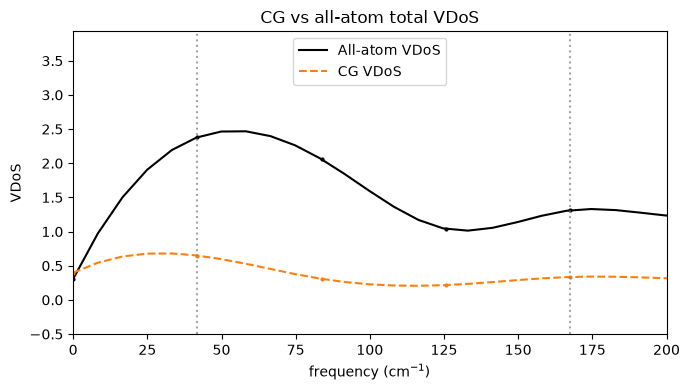

In [5]:
if not np.allclose(freqs_aa, freqs_cg):
    raise ValueError("AA and CG frequency grids differ; check n_corr, dt, and sigma.")

fig, ax = plt.subplots(figsize=(7, 4))
plot_spectra(
    freqs_aa,
    [vdos_aa, vdos_cg],
    ax=ax,
    xlim=(0, 200),
    labels=["All-atom VDoS", "CG VDoS"],
    colors=["black", "tab:orange"],
    linestyles=["-", "--"],
    vlines=freqs_aa[low_peaks_aa].tolist(),
    title="CG vs all-atom total VDoS",
)
# change Gaussian filter window
plt.tight_layout()
plt.show()


## 5. Back-map modes 1 and 2 to all-atom coordinates

Mass-weighted backmap: `u_i = u_b * sqrt(m_i / M_b)` for each atom `i` in bead `b`. Modes are taken from the CG zero-frequency bin when available; otherwise from all-atom FRESEAN at the same bin.


Mode 1 (CG backmap): norm=1.0000, max |AA|=0.4545
Mode 2 (CG backmap): norm=1.0000, max |AA|=0.4197


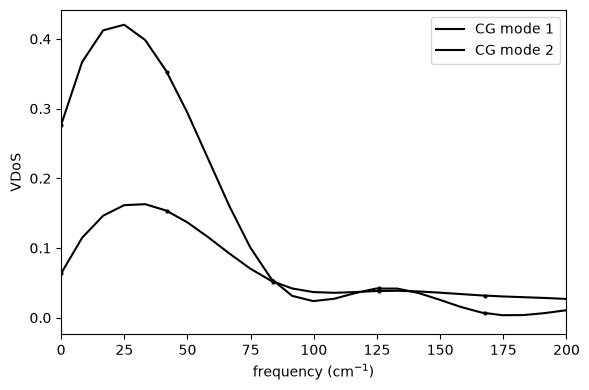

In [ ]:
eigenvectors_aa = analysis_aa.results.eigenvectors
zero_freq_idx_aa = int(low_peaks_aa[0])
masses = cg._atom_masses()
n_atoms = cg.atomgroup.n_atoms

aa_modes = []
for mode_num, mode_idx in zip(MODE_NUMBERS, MODE_INDICES):
    if mode_idx < eigenvectors_cg.shape[1]:
        cg_mode = eigenvectors_cg[zero_freq_idx_cg, mode_idx]
        aa_mode = cg.backmap_modes(cg_mode)
        source = "CG backmap"
        cg_norm = np.linalg.norm(cg_mode) # check this!
    elif mode_idx < eigenvectors_aa.shape[1]:
        weighted = eigenvectors_aa[zero_freq_idx_aa, mode_idx].reshape(n_atoms, 3)
        aa_mode = weighted / np.sqrt(masses)[:, np.newaxis]
        source = "all-atom FRESEAN"
        cg_norm = np.linalg.norm(weighted)
    else:
        raise ValueError(
            f"Mode {mode_num} not available: CG has {eigenvectors_cg.shape[1]} modes, "
            f"all-atom has {eigenvectors_aa.shape[1]}."
        )
    aa_modes.append(aa_mode)
    print(
        f"Mode {mode_num} ({source}): norm={cg_norm:.4f}, "
        f"max |AA|={np.max(np.linalg.norm(aa_mode, axis=1)):.4f}"
    )

mode_vdos_cg = mode_spectra( # explain and reference in markdown!
    corr_cg,
    eigenvectors_cg[zero_freq_idx_cg, list(MODE_INDICES)],
)
fig, ax = plt.subplots(figsize=(6, 4))
for i, mode_num in enumerate(MODE_NUMBERS):
    plot_spectra(freqs_cg, mode_vdos_cg[i], ax=ax, labels=f"CG mode {mode_num}")
ax.set_xlim(0, 200)
plt.tight_layout()
plt.show()


## 6. PLUMED mode input

`write_plumed_mode_input()` writes `plumed-mode-input.pdb` (reference structure plus modes 1 and 2). For the full HEWL metadynamics workflow see `05_CG-hewl.ipynb`.


In [7]:
plumed_input = OUT / "plumed-mode-input.pdb"
cg.write_plumed_mode_input(aa_modes, str(plumed_input))

for mode_num, aa_mode in zip(MODE_NUMBERS, aa_modes):
    cg.write_plumed_direction_pdb(aa_mode, str(OUT / f"evec_{mode_num}_aa_scaled.pdb"))

print(f"Wrote {plumed_input}")


Wrote output_data/MD-gas-300K-CG/plumed-mode-input.pdb


## 7. Un-coarse-grain: `track` vs `ref`

**File roundtrip:** §1 writes `cg_map.npz`, `traj-cg.trr`, and `aa_rotations.npz` (per-frame COM-relative displacement vectors). Load CG + vectors from disk, `backmap_positions`, compare to `aa_sel` from §1.

**VDoS plot:** track vs ref using aligned `u_cg` from §2.

/home/athiru12/.local/lib/python3.13/site-packages/MDAnalysis/topology/ITPParser.py:646: DeprecationWarning: The elements attribute has been populated by guessing elements from atom types. This behaviour has been temporarily added to the ITPParser as we transition to the new guessing API. This behavior will be removed in release 3.0. Please see issue #4698 for more information. 
  warnings.warn(
/home/athiru12/.local/lib/python3.13/site-packages/MDAnalysis/coordinates/XDR.py:261: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn(


File roundtrip max error (Å): 4.77e-07
OK: CG files + centered vectors recover §1 all-atom coordinates.


/home/athiru12/.local/lib/python3.13/site-packages/MDAnalysis/coordinates/PDB.py:479: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn(


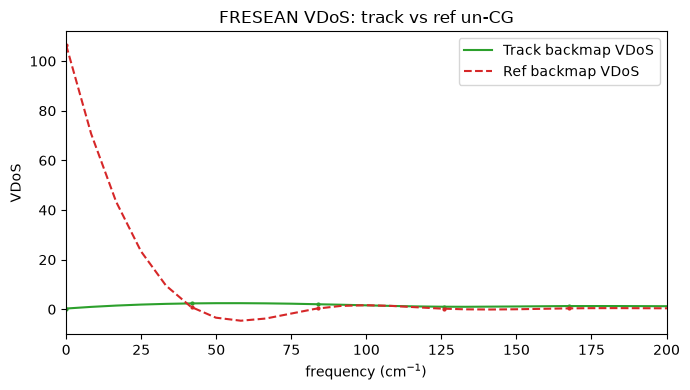

In [8]:
# Load CG trajectory + centered vectors from disk (written in §1, before §2 alignment).
centered_traj, _, _ = CoarseGrain.load_centered_deltas(aa_rotations_path)
u_cg_disk = mda.Universe(str(cg_top), str(cg_traj), topology_format="ITP")
cg._restore_bead_masses(u_cg_disk)

# Roundtrip: disk CG COMs + saved COM-relative vectors → AA coords (compare to §1 aa_sel).
max_err = 0.0
for frame in range(N_FRAMES):
    aa_sel.universe.trajectory[frame]
    u_cg_disk.trajectory[frame]
    rebuilt = cg.backmap_positions(
        u_cg_disk.atoms.positions,
        centered_traj[frame],
    )
    err = np.max(np.abs(rebuilt - aa_sel.positions))
    max_err = max(max_err, err)
    np.testing.assert_allclose(rebuilt, aa_sel.positions, atol=1e-3)
print(f"File roundtrip max error (Å): {max_err:.2e}")
print("OK: CG files + centered vectors recover §1 all-atom coordinates.")

# Optional: full AA universe on disk (for inspection / FRESEAN below).
u_aa_back = cg.reconstruct_aa_universe(
    u_cg_disk,
    centered=aa_rotations_path,
)

# --- VDoS: track vs ref (aligned u_cg from §2) ---
# For track backmap on the *aligned* CG traj, recompute COM-relative vectors
# from the aligned all-atom coords at each frame (not the §1 disk file).
centered_aligned = []
centered_vel_aligned = []
for frame in range(N_FRAMES):
    u_aa_fresh.trajectory[frame]
    centered_aligned.append(cg.compute_centered_coords(sel_aa.positions))
    centered_vel_aligned.append(cg.compute_centered_velocities(sel_aa.velocities))

u_aa_track = CoarseGrain.aa_universe_from_cg(
    mapping=cg,
    u_cg=u_cg,
    centered=np.asarray(centered_aligned),
    centered_velocities=np.asarray(centered_vel_aligned),
)

# ref — omit centered (mapping reference-frame vectors only)
u_aa_ref = CoarseGrain.aa_universe_from_cg(mapping=cg, u_cg=u_cg)

def run_aa_fresean(universe):
    sel = universe.select_atoms("all")
    universe.trajectory.add_transformations(
        Align(sel, reference_positions=ref_positions, place_com_in_box=False),
    )
    analysis = FRESEAN(
        universe,
        select="all",
        n_constraints=N_CONSTRAINTS_AA,
        n_corr=N_CORR,
        dt=DT,
        sigma=SIGMA,
    )
    analysis.run(stop=N_FRAMES)
    return analysis.results.freqs, analysis.results.vdos_total


freqs_track_aa, vdos_track_aa = run_aa_fresean(u_aa_track)
freqs_ref_aa, vdos_ref_aa = run_aa_fresean(u_aa_ref)

fig, ax = plt.subplots(figsize=(7, 4))
plot_spectra(
    freqs_track_aa,
    [vdos_track_aa, vdos_ref_aa],
    ax=ax,
    xlim=(0, 200),
    labels=["Track backmap VDoS", "Ref backmap VDoS"],
    colors=["tab:green", "tab:red"],
    linestyles=["-", "--"],
    title="FRESEAN VDoS: track vs ref un-CG",
)
plt.tight_layout()
plt.show()